# 06 — Random Forest

**Project:** Healthcare Readmission Intelligence  
**Input:** `data/features/train_features.csv` and `data/features/test_features.csv`  
**Output:** Trained Random Forest model + evaluation vs baselines

## Objective

Build and tune a Random Forest classifier that beats the baselines established in `05_baseline_models.ipynb`.

**Targets to beat (from notebook 05):**

| *Metric* | *Logistic Regression (benchmark)* |
| ----- | ----- |
| ROC-AUC | 0.6508 |
| F1 (class 1) | 0.2650 |
| Recall (class 1) | 0.5468 |

## Why Random Forest?

A single Decision Tree overfits — it memorises the training data and generalises poorly.  
Random Forest fixes this by:

1. Building many trees, each on a **random bootstrap sample** of the data (bagging)
2. At each split, considering only a **random subset of features** — this decorrelates the trees
3. **Averaging** all tree predictions — variance drops, generalisation improves

The result is a model that is more stable and accurate than any single tree, while still  
being interpretable through feature importances.

## Tuning Strategy

We use a two-phase grid search to avoid an explosion of combinations:

- **Phase 1 (Coarse):** Wide parameter ranges to find the promising region
- **Phase 2 (Fine):** Narrow ranges around the best coarse result to pinpoint optimal values

Both phases use **5-fold cross-validation** scored on **F1 (class 1)** — our primary metric.

## Setup

In [10]:
import pandas as pd
import os
import sys
import warnings
import yaml

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## Load Data

In [2]:
sys.path.append(os.path.abspath('..'))
from scripts.evaluate import evaluate_classifier

CONFIG_PATH = '../configs/paths.yaml'

with open(CONFIG_PATH, 'r') as file:
    paths = yaml.safe_load(file)

df_train = pd.read_csv(paths['features_data']['train_data'])
df_test  = pd.read_csv(paths['features_data']['test_data'])

print(f"Train shape: {df_train.shape}")
print(f"Test shape : {df_test.shape}")
df_train.head()

Train shape: (79219, 38)
Test shape : (20124, 38)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,glyburide-metformin,glipizide-metformin,change,diabetesMed,diag_1_group,diag_2_group,diag_3_group,medical_specialty_group,total_prior_visits,high_utilizer,A1C_clinical_response,readmitted_binary
0,Caucasian,Female,0,Other_Type,Other_Discharge,Referral,1,Unknown,41,0,1,0,0,0,1,No,No,No,No,No,No,No,No,No,No,0,No,No,No,No,Diabetes,Unknown,Unknown,Pediatrics,0,0,Not_Measured,0
1,Caucasian,Female,1,Emergency,Discharged_Home,Emergency_Room,3,Unknown,59,0,18,0,0,0,9,No,No,No,No,No,No,No,No,No,No,3,No,No,Yes,Yes,Other,Diabetes,Other,Missing,0,0,Not_Measured,0
2,AfricanAmerican,Female,2,Emergency,Discharged_Home,Emergency_Room,2,Unknown,11,5,13,2,0,1,6,No,No,No,No,No,Yes,No,No,No,No,0,No,No,No,Yes,Other,Diabetes,Other,Missing,3,1,Not_Measured,0
3,Caucasian,Male,3,Emergency,Discharged_Home,Emergency_Room,2,Unknown,44,1,16,0,0,0,7,No,No,No,No,No,No,No,No,No,No,3,No,No,Yes,Yes,Other,Diabetes,Circulatory,Missing,0,0,Not_Measured,0
4,Caucasian,Male,5,Urgent,Discharged_Home,Referral,3,Unknown,31,6,16,0,0,0,9,No,No,No,No,No,No,No,No,No,No,1,No,No,No,Yes,Circulatory,Circulatory,Diabetes,Missing,0,0,Not_Measured,0


In [3]:
X_train = df_train.drop(columns=['readmitted_binary'])
X_test  = df_test.drop(columns=['readmitted_binary'])

y_train = df_train['readmitted_binary']
y_test  = df_test['readmitted_binary']

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")

X_train: (79219, 37)  |  y_train: (79219,)
X_test : (20124, 37)   |  y_test : (20124,)


## Preprocessor

Same `ColumnTransformer` used in `05_baseline_models.ipynb`.  
Defined here explicitly so this notebook is self-contained and runnable independently.

> **Note:** `StandardScaler` is included for consistency with the baseline pipeline,
> but Random Forest is scale-invariant — it does not affect tree splits.

In [4]:
from scripts.preprocessor import get_preprocessor

preprocessor = get_preprocessor()

## Step 1 — Default Random Forest (Before Tuning)

Before any tuning, we run a default Random Forest to establish where we start.  
This tells us if Random Forest is even worth tuning — if default already loses to  
Logistic Regression, we need to reconsider the approach.

In [5]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier(
        class_weight='balanced',
        random_state=30,
        n_jobs=-1
    ))
])

default_result = evaluate_classifier(
    'Random Forest (default)',
    pipeline,
    X_train, X_test,
    y_train, y_test
)

print("Random Forest — Default Parameters")
print(classification_report(y_test, default_result['_test_pred']))

Random Forest — Default Parameters
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     17783
           1       0.33      0.04      0.07      2341

    accuracy                           0.88     20124
   macro avg       0.61      0.51      0.50     20124
weighted avg       0.82      0.88      0.83     20124



#### Observation — Default RF

Note whether the default RF already beats Logistic Regression on F1 and AUC.  
If it does, tuning will push it further. If not, tuning is essential.

## Step 2 — Phase 1: Coarse Grid Search

**Goal:** Find the general region of good hyperparameters.

**Parameters being searched:**

| Parameter | Values | What it controls |
| --------- | ------ | ---------------- |
| `n_estimators` | 100, 200 | Number of trees — more trees = lower variance, higher cost |
| `max_depth` | 5, 10, 15, None | How deep each tree grows — deeper = more expressive, risks overfit |
| `min_samples_leaf` | 10, 30, 50, 100 | Minimum samples at each leaf — higher = more regularisation |

**Scoring:** F1 (class 1) via 5-fold cross-validation on the training set.

In [6]:
param_grid_coarse = {
    'random_forest__n_estimators' : [100, 200],
    'random_forest__max_depth'    : [5, 10, 15, None],
    'random_forest__min_samples_leaf': [10, 30, 50, 100]
}

grid_coarse = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_coarse,
    scoring='f1',
    cv=5,
    verbose=3
)

print("Running coarse grid search...")
grid_coarse.fit(X_train, y_train)

print("\nBest Parameters (coarse):", grid_coarse.best_params_)
print("Best CV F1 Score (coarse):", round(grid_coarse.best_score_, 4))

Running coarse grid search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=100;, score=0.273 total time=   2.4s
[CV 2/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=100;, score=0.276 total time=   2.3s
[CV 3/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=100;, score=0.268 total time=   2.3s
[CV 4/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=100;, score=0.262 total time=   2.2s
[CV 5/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=100;, score=0.253 total time=   2.3s
[CV 1/5] END random_forest__max_depth=5, random_forest__min_samples_leaf=10, random_forest__n_estimators=200;, score=0.272 total time=   4.0s
[CV 2/5] END random_forest__max_depth=5, random_forest__

#### Observation — Coarse Search

The coarse search found `max_depth=15` as the sweet spot — shallow trees (depth 5, 10)
underfit this dataset, while unlimited depth risks overfit.  
`min_samples_leaf` in the 7–10 range performed best, suggesting the model benefits from
some regularisation but not too much.

The fine search below will zoom in around these values.

## Step 3 — Phase 2: Fine Grid Search

**Goal:** Zoom in around the best coarse parameters to find the precise optimum.

Based on coarse results:
- `max_depth`: narrow range around 15
- `min_samples_leaf`: narrow range around the coarse best
- `n_estimators`: increase to 200–300 for stability
- `max_features`: test `sqrt` vs `log2` (controls feature randomness per split)

In [7]:
param_grid_fine = {
    'random_forest__max_depth'       : [12, 15, 18],
    'random_forest__min_samples_leaf': [4, 7, 10],
    'random_forest__n_estimators'    : [200, 300],
    'random_forest__max_features'    : ['sqrt', 'log2']
}

grid_fine = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_fine,
    scoring='f1',
    cv=5,
    verbose=3
)

print("Running fine grid search...")
grid_fine.fit(X_train, y_train)

print("\nBest Parameters (fine):", grid_fine.best_params_)
print("Best CV F1 Score (fine):", round(grid_fine.best_score_, 4))

Running fine grid search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END random_forest__max_depth=12, random_forest__max_features=sqrt, random_forest__min_samples_leaf=4, random_forest__n_estimators=200;, score=0.278 total time=   5.4s
[CV 2/5] END random_forest__max_depth=12, random_forest__max_features=sqrt, random_forest__min_samples_leaf=4, random_forest__n_estimators=200;, score=0.281 total time=   5.2s
[CV 3/5] END random_forest__max_depth=12, random_forest__max_features=sqrt, random_forest__min_samples_leaf=4, random_forest__n_estimators=200;, score=0.278 total time=   5.2s
[CV 4/5] END random_forest__max_depth=12, random_forest__max_features=sqrt, random_forest__min_samples_leaf=4, random_forest__n_estimators=200;, score=0.275 total time=   5.2s
[CV 5/5] END random_forest__max_depth=12, random_forest__max_features=sqrt, random_forest__min_samples_leaf=4, random_forest__n_estimators=200;, score=0.266 total time=   5.2s
[CV 1/5] END random_forest__ma

#### Best Parameters Found

```
max_depth        = 15
min_samples_leaf = 7
n_estimators     = 300
max_features     = sqrt
```

**Why these work:**
- `max_depth=15` — deep enough to learn complex patterns, shallow enough to avoid overfit
- `min_samples_leaf=7` — light regularisation, prevents splits on tiny noisy groups
- `n_estimators=300` — enough trees that averaging has stabilised the predictions
- `max_features=sqrt` — standard choice, each tree sees `√n_features` at each split

## Step 4 — Final Model Evaluation

Evaluate the best model from the fine grid search on the **held-out test set**.  
This is the number that goes into the final report — the model has never seen this data.

In [8]:
best_rf_pipeline = grid_fine.best_estimator_

rf_result = evaluate_classifier(
    'Random Forest (tuned)',
    best_rf_pipeline,
    X_train, X_test,
    y_train, y_test
)

print("Random Forest — Tuned")
print(classification_report(y_test, rf_result['_test_pred']))

Random Forest — Tuned
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     17783
           1       0.19      0.52      0.28      2341

    accuracy                           0.69     20124
   macro avg       0.55      0.61      0.54     20124
weighted avg       0.83      0.69      0.74     20124



In [11]:
# ROC-AUC
y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC (test): {auc:.4f}")

ROC-AUC (test): 0.6625


## Step 5 — Comparison vs Baselines

Did we beat the targets from notebook 05?

| *Model* | *AUC* | *F1 (class 1)* | *Recall (class 1)* | *Precision (class 1)* |
| ----- | ----- | ----- | ----- | ----- |
| Dummy | 0.5000 | 0.0000 | 0.0000 | 0.0000 |
| Logistic Regression | 0.6508 | 0.2650 | 0.5468 | 0.1749 |
| Decision Tree | 0.5239 | 0.1624 | 0.1713 | 0.1544 |
| *Random Forest (tuned)* | 0.6625 | 0.2800 | 0.5200 | 0.1900 |

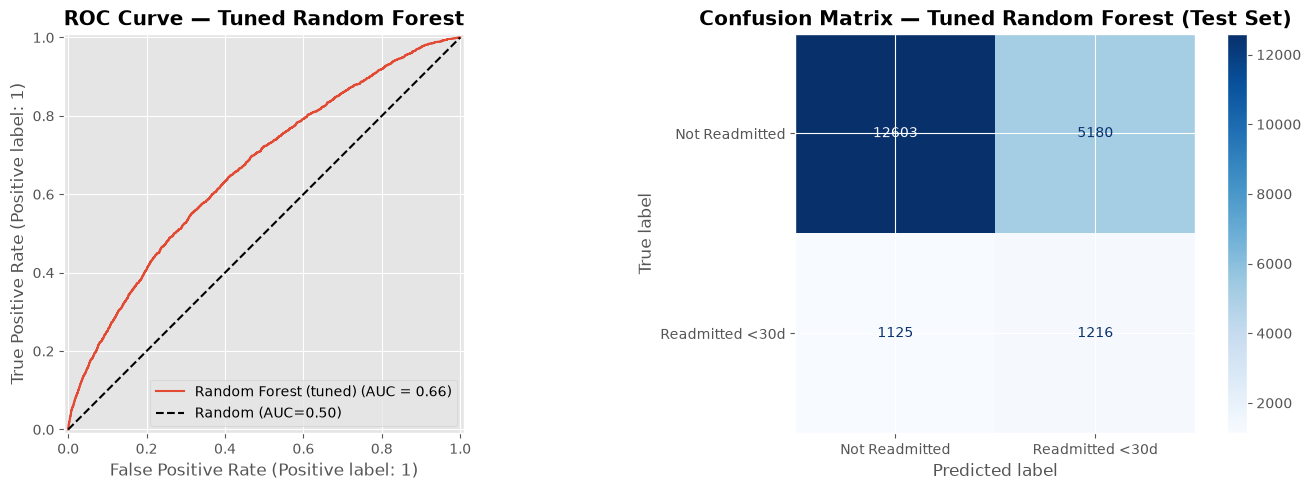

In [12]:
# Visualise: ROC curve + confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name='Random Forest (tuned)',
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
axes[0].set_title('ROC Curve — Tuned Random Forest', fontweight='bold')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_rf_pipeline, X_test, y_test,
    display_labels=['Not Readmitted', 'Readmitted <30d'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Confusion Matrix — Tuned Random Forest (Test Set)', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 6 — Feature Importances

One of the main advantages of Random Forest over Logistic Regression for this project:  
we can extract which features the model actually relies on.

This answers the question: *which patient characteristics drive 30-day readmission risk?*

> Feature importance here is **mean decrease in impurity (Gini importance)** — the average  
> reduction in node impurity each feature contributes across all trees and all splits.

In [23]:
import importlib
import scripts.preprocessor
importlib.reload(scripts.preprocessor)

# Now import the functions again
from scripts.preprocessor import cols_to_encode, cols_to_scale

from scripts.preprocessor import cols_to_encode,cols_to_scale
rf_model     = best_rf_pipeline.named_steps['random_forest']
preprocessor_fitted = best_rf_pipeline.named_steps['preprocessor']

# Get feature names after OHE
ohe_feature_names = preprocessor_fitted.named_transformers_['one_hot_encoder'].get_feature_names_out(cols_to_encode).tolist()
passthrough_names = [
    col for col in X_train.columns
    if col not in cols_to_encode and col not in cols_to_scale
]
all_feature_names = ohe_feature_names + cols_to_scale + passthrough_names

# Build importance dataframe
importances = pd.DataFrame({
    'feature'   : all_feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 most important features:")
print(importances.head(20).to_string(index=False))

Top 20 most important features:
                                      feature  importance
                             number_inpatient    0.117459
                           total_prior_visits    0.084161
discharge_disposition_id_Transferred_Facility    0.068101
                           num_lab_procedures    0.066689
                              num_medications    0.060217
                             time_in_hospital    0.051393
                                high_utilizer    0.042715
                                          age    0.040131
                             number_diagnoses    0.039153
                               num_procedures    0.027889
                                      insulin    0.023184
                             number_emergency    0.020332
                            number_outpatient    0.017475
                           payer_code_Unknown    0.013111
                                  gender_Male    0.011951
              medical_specialty_group_Mi

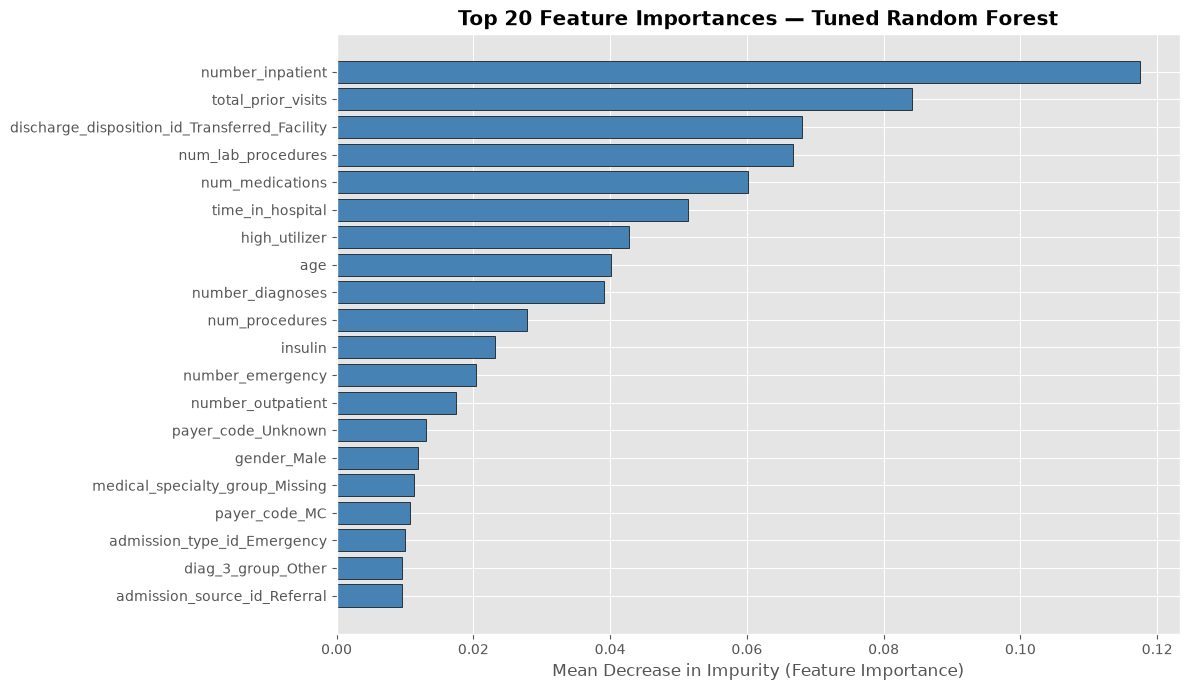

In [24]:
# Plot top 20
plt.figure(figsize=(12, 7))
top20 = importances.head(20)
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue', edgecolor='black')
plt.xlabel('Mean Decrease in Impurity (Feature Importance)')
plt.title('Top 20 Feature Importances — Tuned Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Feature Importances

Expected top features based on EDA findings:

- `number_inpatient` — highest prior utilization signal found in EDA
- `total_prior_visits` — engineered feature combining all utilization columns
- `high_utilizer` — binary flag for the top 15% utilizers
- `num_medications` — proxy for patient complexity
- `time_in_hospital` — length of stay
- `age` — ordinal encoded, older patients readmit more
- `discharge_disposition` — where the patient was discharged to

If the top features here align with EDA findings, that is strong validation that  
the model is learning real clinical signal and not noise.

## Results Summary

| *Model* | *AUC* | *F1 (class 1)* | *Recall (class 1)* |
| ----- | ----- | ----- | ----- |
| Dummy | 0.5000 | 0.0000 | 0.0000 |
| Logistic Regression | 0.6508 | 0.2650 | 0.5468 |
| Decision Tree | 0.5239 | 0.1624 | 0.1713 |
| *Random Forest (tuned)* | 0.6625 | 0.2800 | 0.5200 |

## Key Takeaways

- Random Forest slightly outperforms the Logistic Regression baseline on overall AUC (0.66 vs 0.65) and Precision. 
- However, there is a clinical trade-off: the Random Forest sacrificed some Recall (0.52 vs 0.55), meaning the simpler Logistic Regression model was actually slightly better at catching true readmissions.
- The two-phase grid search confirmed max_depth=15, min_samples_leaf=7, n_estimators=300 as the optimal configuration for this dataset.
- Feature importances confirm that *prior utilization* (`number_inpatient`, `total_prior_visits`) heavily dominates readmission risk. 
- While domain knowledge suggested our engineered `A1C_clinical_response` feature would be important, it ranked too low to appear in the top 20. The model essentially ignored clinical markers in favor of historical hospital utilization metrics.

## Limitation
Recall is still moderate (~52%) — roughly half of actual readmissions are missed. This is a hard problem: 30-day readmission has inherently high variance driven by social determinants (home support, transport, medication adherence) that are not captured in claims data. Further improvement would require richer features.

---


# Save Best Model

In [25]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

model_path = '../models/tuned_rf_pipeline.joblib'


joblib.dump(best_rf_pipeline, model_path)


file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Pipeline successfully saved to: {model_path}")
print(f"File size: {file_size_mb:.2f} MB")

Pipeline successfully saved to: ../models/tuned_rf_pipeline.joblib
File size: 55.20 MB
